In [11]:
#!pip install deepface tf-keras opencv-python -q

In [5]:
import cv2, pickle, numpy as np
from deepface import DeepFace
from IPython.display import Image, display

PKL_FILE  = 'face_embeddings.pkl'  
MY_NAME   = 'Surya'
THRESHOLD = 0.50 

with open(PKL_FILE, 'rb') as f:
    data = pickle.load(f)

MY_EMBEDDINGS = [np.array(d['embedding']).flatten() for d in data]
print(f'Loaded {len(MY_EMBEDDINGS)} embeddings for {data[0]["name"]}')

def cos_dist(a, b):
    a = a / (np.linalg.norm(a) + 1e-9)
    b = b / (np.linalg.norm(b) + 1e-9)
    return 1.0 - float(np.dot(a, b))

def get_emb(face_img):
    face_bgr = cv2.cvtColor((face_img * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
    r = DeepFace.represent(face_bgr, model_name='ArcFace',
                           detector_backend='skip', enforce_detection=False)
    return np.array(r[0]['embedding']).flatten()

def label_faces(frame):
    try:
        faces = DeepFace.extract_faces(frame, detector_backend='retinaface',
                                       enforce_detection=False, align=True)
    except:
        return frame
    for det in faces:
        r = det['facial_area']
        x, y, w, h = r['x'], r['y'], r['w'], r['h']
        try:
            emb  = get_emb(det['face'])
            dist = min(cos_dist(emb, ref) for ref in MY_EMBEDDINGS)
            if dist < THRESHOLD:
                label, color = f'{MY_NAME} ({dist:.2f})', (0, 255, 0)
            else:
                label, color = f'Unknown ({dist:.2f})', (0, 0, 255)
        except Exception as e:
            label, color = f'Err:{e}', (128, 128, 128)
        cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)
        cv2.putText(frame, label, (x, y-8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    return frame

print('Ready!')

Loaded 379 embeddings for Surya
Ready!


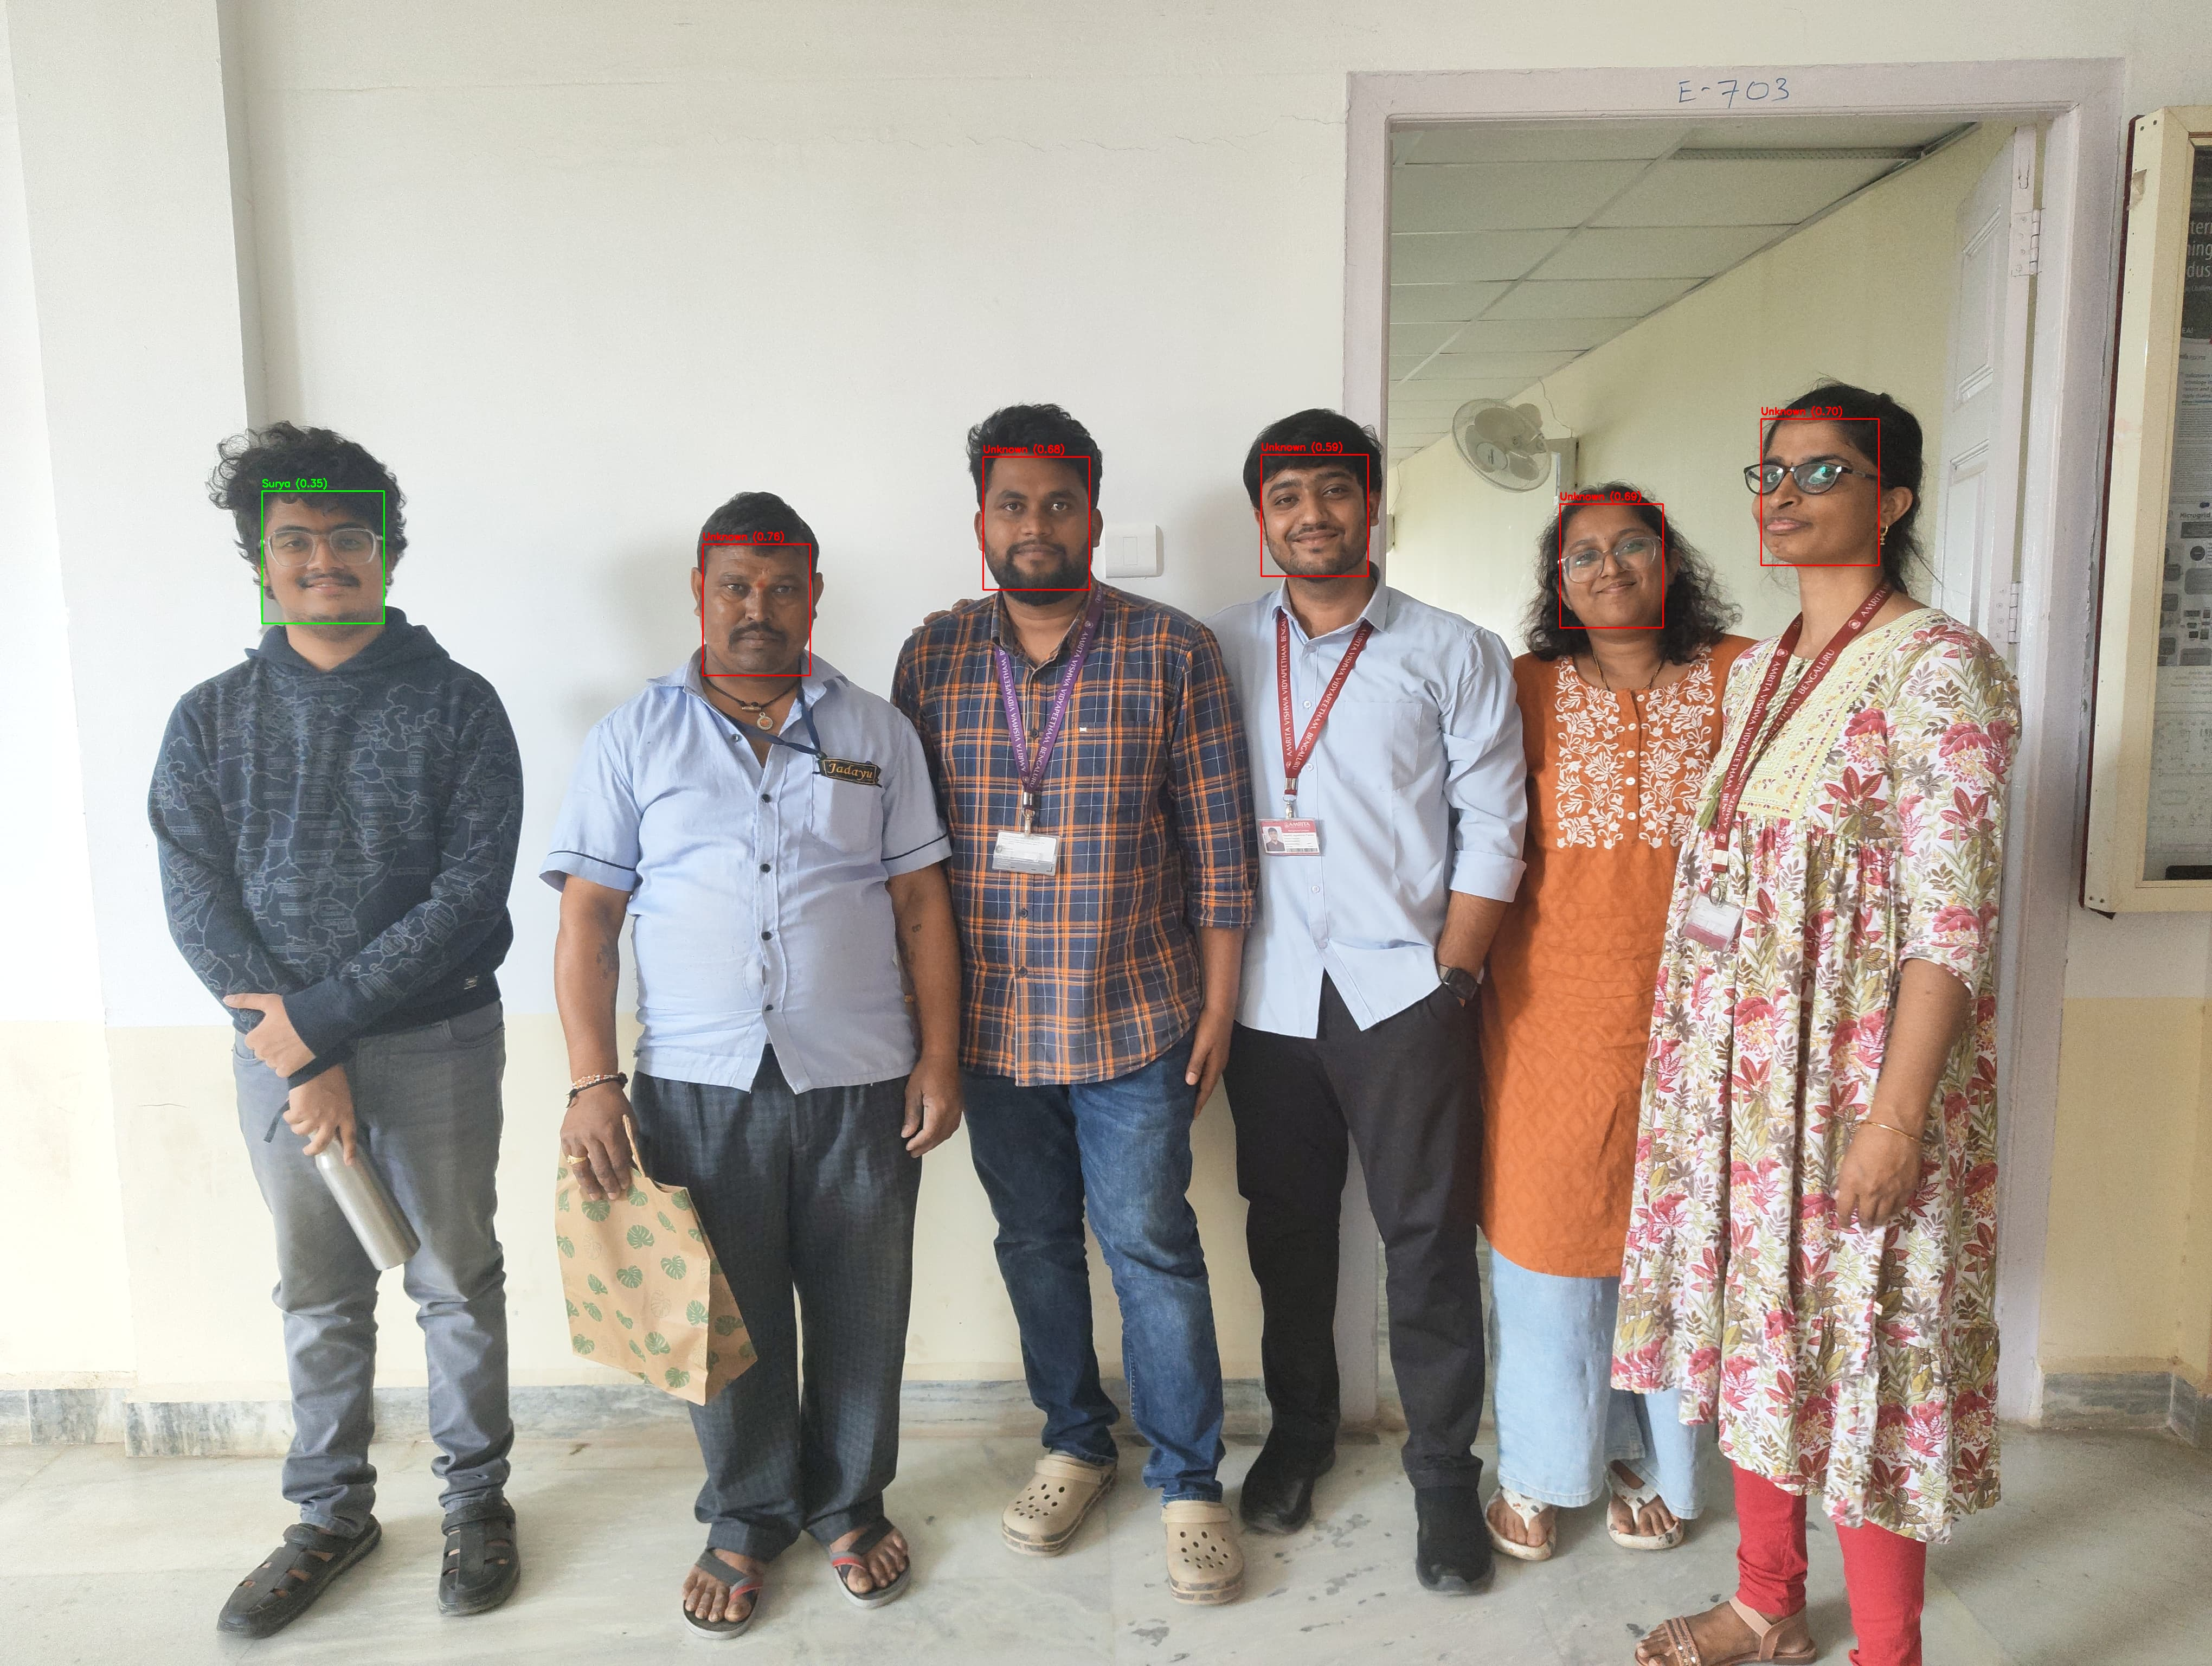

Saved → result_photo.jpg


In [6]:
PHOTO_PATH  = 'C:\\Users\\chsur\\Downloads\\frk\\up\\IMG-20251112-WA0018.jpg'   
OUTPUT_PATH = 'result_photo.jpg'

img    = cv2.imread(PHOTO_PATH)
result = label_faces(img.copy())
cv2.imwrite(OUTPUT_PATH, result)

display(Image(OUTPUT_PATH))
print(f'Saved → {OUTPUT_PATH}')

In [7]:
VIDEO_IN  = 'VID20220130141945.mp4'   
VIDEO_OUT = 'result_video.mp4'
SKIP      = 5               

cap    = cv2.VideoCapture(VIDEO_IN)
fps    = cap.get(cv2.CAP_PROP_FPS) or 25
W      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
writer = cv2.VideoWriter(VIDEO_OUT, cv2.VideoWriter_fourcc(*'mp4v'), fps, (W, H))

last_frame, idx = None, 0
while True:
    ret, frame = cap.read()
    if not ret: break
    if idx % SKIP == 0:
        last_frame = label_faces(frame.copy())
    writer.write(last_frame if last_frame is not None else frame)
    idx += 1
    if idx % 50 == 0: print(f'  {idx}/{total} frames done...')

cap.release(); writer.release()
print(f' Saved → {VIDEO_OUT}')

  50/119 frames done...
  100/119 frames done...
 Saved → result_video.mp4


In [ ]:
import time
SKIP_CAM = 10   # higher = faster but less smooth

cap, idx, last = cv2.VideoCapture(0), 0, None
while True:
    ret, frame = cap.read()
    if not ret: break
    if idx % SKIP_CAM == 0:
        last = label_faces(frame.copy())
    show = last if last is not None else frame
    cv2.putText(show, 'Q = quit', (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,0), 2)
    cv2.imshow('Face Recognition', show)
    if cv2.waitKey(1) & 0xFF == ord('q'): break
    idx += 1

cap.release(); cv2.destroyAllWindows()
print(' Webcam closed')